# Reactivities (Functional Groups v2)

> ### In this tutorial we will cover:
> - how we can use the `Reactivity` classes to automatically connect Molecules based on functional groups

> ### NOTE: 
> The `Reactivity` classes are the **successors** of the previous `FunctionalGroup` classes. The functional groups are still part of the codebase, however, and can be used or extended at will.

BuildAMol offers great flexibility when connecting molecules. It is designed create any kind of single-bond between any two atoms and is *not* restrained to work in the realm of the "chemically plausible". 

However, BuildAMol does know about some functional groups. The (by now 'old') `FunctionalGroup` classes defined groups of atoms based on their geometric arrangement in space using a central atom. This allowed for rapid identification of suitable atom groups but limited the number of representable functional groups (e.g. larger groups without a meaningful 'central atom' could not be processed).

Therefore the new `Reactivity` classes were written to work specifically in conjuction with the `Reaction` class. The basic idea behind a `Reactivity` is that it defines functions to search atoms that can serve as `linker` and `deleter` atoms when defining `Linkages`. The main difference between the old `FunctionalGroup` and `Reactivity` classes is that the latter can accept arbitrary functions to determine the suitable atoms. The pre-defined reactivities of some common functional groups mostly rely on the atom connectivity graphs of the molecules and do not consider the spatial arrangement of atoms in space anymore. 

Let us recycle the same example that was used in the old Functional Groups tutorial. 

Let's say we want to connect benzaldehyde to m-Toluidine like so:

![](./files/reaction1.png)

So we want to connect the aldehyde of benzaldehyde to the amine of m-Toluidine. 

In [1]:
import buildamol as bam
bam.visual.set_backend("py3dmol")

bam.load_small_molecules()

# first make the component molecules
benzaldehyde = bam.molecule("benzaldehyde")
toluidine = bam.molecule("m-toluidine")

Now that we have our component molecules, we can connect them. Instead of looking at them and identifying the atoms manually we will now use the `Reactivity` classes for the `Amine` and `Aldehyde` to define a `Reaction` that will link our molecules together. Here's how:

## Making a Reaction

We can use the classmethod `Reaction.from_reactivities` to setup our reaction in the desired way, specifying that the amine will serve as nucleophile and the aldehyde as electrophile. 
By default the electrophile is considered the `target` molecule and the nucleophile the `source`. If your setup is different add `target_is_electrophile=False` to the classmethod call. 

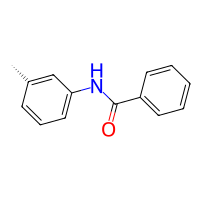

In [2]:
# import the reactivities we want to use
from buildamol.structural.reactivity import Amine, Aldehyde

# setup the reaction
reaction = bam.Reaction.from_reactivities(
    nucleophile=Amine(),
    electrophile=Aldehyde()
)

# now we can make the product
product = reaction(target=benzaldehyde, source=toluidine)
product.draw2d().draw(width=200, height=200)

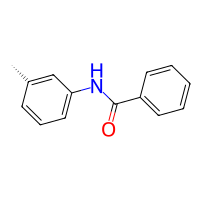

In [3]:
# just for reference, this is how the old functional group way would look like:
from buildamol.structural.groups import amine, aldehyde
product_old = bam.react(benzaldehyde, toluidine, egroup=aldehyde, ngroup=amine)
product_old.draw2d().draw(width=200, height=200)

As we can appreciate, setting up this basic reaction is straightforward - both with the reactivities and functional groups. Since both are roughly equal effort you might wonder why we created the reactivities in the first place. The reason is that the reactivities are much easier to define and they support larger leaving groups. If you checked out the tutorial of the functional groups and you read the part of defining a custom "nitro" group you may remember that the definition is not in itself a lot of effort but is definitely far from inuitive or beginner friendly. However, reactivities are much easier and flexible to work with. 

## Custom Reactivities 

Let's also recreate a custom reactivity for a nitro group just like we did in the functional groups tutorial. 

To define a custom functional group we need to define functions to obtain linker atoms from a `Molecule` instance. Optionally, we may define functions to also define deleter atoms based on a linker `Atom` and the corresponding `Molecule` instance. 

We can define reactivity for either `nucleophile` or `electrophile` behaviours (or both). 

The easiest way to define a custom reactivity is to subclass the `Reactivity` class. Here's how to do it:

In [4]:
# we are going to search for the right atoms using connectivity constraints
# (the v2 constraints are better than the old ones)
from buildamol.structural import constraints_v2 as constraints

class Nitro(bam.structural.Reactivity):
    """Custom Nitro reactivity"""

    # if we want the nitro group to act as an electrophile
    # we need to define an electrophile_linker method
    def electrophile_linker(self, mol):
        # we are looking for a nitrogen atom
        # with connectivity pattern N(=O)O
        filters = constraints.and_(
            constraints.has_double_bond_with("O"),
            constraints.has_single_bond_with("O"),
        )
        N = mol.get_atoms("N", by="element", filter=filters)
        return N
    
    # we want the nitro group to lose one oxygen as leaving group
    # therefore we also need to define an electrophile_deleter method
    def electrophile_deleter(self, atom, mol):
        filters = constraints.and_(
            constraints.has_element("O"),
            constraints.has_single_bond_with("N"),
        )
        O = mol.get_neighbors(atom, filter=filters).pop()
        return O

And with that we have defined the reactivity of our Nitro group in case it should act as an electrophile (without being itself the full leaving group). We can now test it out by letting an amine perform an attack on a nitro-containing molecule. 

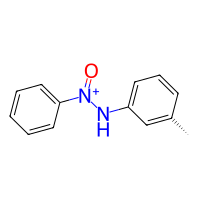

In [5]:
nitro_benzene = bam.read_smiles("C1=CC=C(C=C1)[N+](=O)[OH]")

# setup the reaction
reaction_nitro = bam.Reaction.from_reactivities(
    nucleophile=Amine(),
    electrophile=Nitro()
)

# now we can make the product
product_nitro = reaction_nitro(nitro_benzene, toluidine)
product_nitro.draw2d().draw(width=200, height=200)

And that's it! Of course our custom Nitro reactivity is only defined for the case that we are using it as an electrophile. We could add methods `nucleophile_linker` and `nucleophile_deleter` to let the group do both:

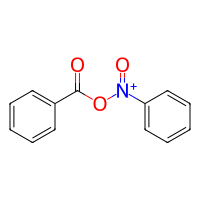

In [6]:
# we simply add a nucleophile_linker method to the Nitro class
# that will obtain the O neighbor of the electrophilic N=O group
class NitroWithNucleophile(Nitro):
    def nucleophile_linker(self, mol):
        electrophile_N = self.electrophile_linker(mol)
        nucleophile_O = []

        filters = constraints.and_(
            constraints.has_element("O"),
            constraints.has_single_bond_with("N"),
        )
        for N in electrophile_N:
            O = mol.get_neighbors(N, filter=filters).pop()
            nucleophile_O.append(O)
        return nucleophile_O
    

# now we can use the new reactivity to also let the nitro group act as a nucleophile
reaction = bam.Reaction.from_reactivities(
    nucleophile=NitroWithNucleophile(),
    electrophile=Aldehyde(),
    target_is_electrophile=False,
)
product = reaction(nitro_benzene, benzaldehyde)
product.draw2d().draw(width=200, height=200)

## Multiple Target Sites

You may have noticed that the `nucleophile_linker` method of the `NitroWithNucleophile` class did not simply return an Atom but a list of Atoms. Does that mean that Reactivities would support performing multiple attachments at the same time? Yes, that's exactly what it means! With the little caveat that multiple attachment points are only supported for the _target_ molecule (i.e. a reaction can automatically attach copies of the source molecule onto multiple target linker atoms). 

To exemplify this with an easier molecule, let's look at the following:

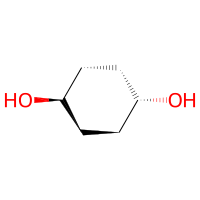

In [7]:
cyclohexanol = bam.read_smiles("C1(O)CCC(O)CC1")
cyclohexanol.draw2d().draw(width=200, height=200)

The cyclohexan-diol has two hydroxyl groups. If we now let it react with the toluidine, **both** hydroxyl groups will form new bonds because the the `Hydroxyl` reactivity also returns lists of Atoms just like we did in our custom Nitro class. 

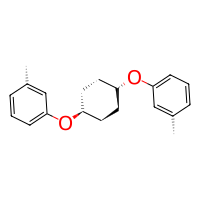

In [8]:
from buildamol.structural.reactivity import Hydroxyl

reaction = bam.Reaction.from_reactivities(
    nucleophile=Hydroxyl(),
    electrophile=Amine(),
    target_is_electrophile=False,
)
product = reaction(cyclohexanol, toluidine)
product.draw2d().draw(width=200, height=200)


or inversely as electrophile

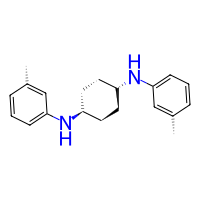

In [9]:
reaction = bam.Reaction.from_reactivities(
    nucleophile=Amine(),
    electrophile=Hydroxyl(),
    target_is_electrophile=True,
)
product = reaction(cyclohexanol, toluidine)
product.draw2d().draw(width=200, height=200)

## Steric Constraints 

If we want to limit the reactivity or narrow down the atoms that should react we can either modify the _linker_ methods of the reactivities, or use the `set_steric_constraints` method to finetune the atoms that participate in reactions. We can either provide a custom function to check which atom matches are valid or we can tune the settings of the default "steric hindrance" implementation which checks for the number of atoms in close proximity to the linker atom. We can for example give a maximal number of allowed neighbors in a given region and limit the linker sites only to the N best ones. 

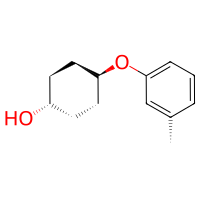

In [10]:
# limit the reactivity to only one of the hydroxyl groups
# (check out the other options in the docstring of set_steric_constraints)
hydroxyl_one = Hydroxyl().set_steric_constraints(n_target_sites=1)

reaction = bam.Reaction.from_reactivities(
    nucleophile=hydroxyl_one,
    electrophile=Amine(),
    target_is_electrophile=False,
)
product = reaction(cyclohexanol, toluidine)
product.draw2d().draw(width=200, height=200)

## Using Reactivities without a Reaction

So far we have looked at using Reactivities together with a Reaction to get linkages automatically without any manual intervention. However, what if we have a specific target atom in mind on one molecule but we want to use a Reactivity on the source atom (or vice versa)? 

In those cases it might look like you just need to define a reactivity that will return the desired atom in the right linker method, right? True, that is one solution.

Another option is defining a custom Reaction and using the Reactivity's `as_nucleophile` or `as_electrophile` methods to obtain the right linker and deleter functions while directly providing the target atoms to the appropriate arguments of the Reaction's init call. 
 
 We can also just use the Reactivity's method `find_atoms` (similar to the old functional groups' `find_matches`) to obtain the right atoms and manually create a Linkage with the right specifics. 

So, in total there is three different options of how to mix manual and automated aspects when it comes to linkage generation with Reactivities and Reactions. 

Let's illustrate the three different approaches below:

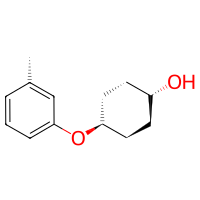

In [ ]:
# (option 1) make a pseudo-reactivity that will return the desired atoms

pseudo_reactivity = bam.structural.Reactivity(
    nucleophile_linker=lambda mol: mol.get_atom("O1", residue=1)
)

reaction = bam.Reaction.from_reactivities(
    nucleophile=pseudo_reactivity,
    electrophile=Amine(),
    target_is_electrophile=False,
)

product = reaction(cyclohexanol, toluidine)
product.draw2d().draw(width=200, height=200)

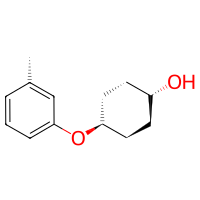

In [ ]:
# (option 2) directly provide arguments to the Reaction 

# get the amine's electrophile-mode search functions
amine_linker, amine_deleter = Amine().as_electrophile(serves_target=False)

# and create a reaction with specific target atom in the cyclohexanol
reaction = bam.Reaction(
    atom1=cyclohexanol.get_atom("O1", residue=1),
    atom2=amine_linker,
    delete_in_source=amine_deleter,
)

product = reaction(cyclohexanol, toluidine)
product.draw2d().draw(width=200, height=200)

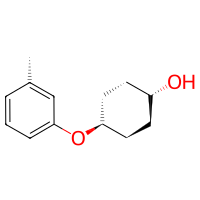

In [ ]:
# (option 3) find atoms first and then create a linkage manually

amine_linker, amine_deleters = Amine().find_electrophilic_atoms(toluidine, serves_target=False)

link = bam.linkage(
    atom1=cyclohexanol.get_atom("O1", residue=1),
    atom2=amine_linker,
    delete_in_source=[amine_deleters],
)

product = bam.connect(cyclohexanol, toluidine, link)
product.draw2d().draw(width=200, height=200)

You will likely agree that the three approaches are nearly equal in the amount of code required to achieve the desired goal. Feel free to use whichever best suits your needs. 

And with that we already reached the end of this tutorial. To summarize, we have seen the `Reactivity` classes that serve as atom search-engines to feed into the `Reaction` class that itself serves as a linkage generator-engine. There are a bunch of reactivities available within BuildAMol directly but defining custom ones is straightforward. Be sure to also check out the tutorial on Reactions directly to see how the two concepts of Reaction and Reactivity work hand in hand - depending on your use-case you may also directly define a reaction with a bunch of functions instead of going the route via a Reactivity object. 

Thanks a lot for sticking around to the end, and best of luck with your project using BuildAMol!